In [1]:
import sys
import os
import tqdm
import matplotlib.pyplot as plt

build_dir = os.path.abspath('./build')
print(f"Build dir: {build_dir}")
print(f"Contents: {os.listdir(build_dir)}")  # ← CRITICAL DEBUG

sys.path.insert(0, build_dir)
if os.path.exists(build_dir):
    if os.name == 'nt':
        os.add_dll_directory(build_dir)

try:
    import tsn
    print("✅ SUCCESS!")
    print(dir(tsn))
except ImportError as e:
    print(f"❌ Import failed: {e}")
    print("Trying direct import...")
    # List all .pyd files and try importing
    for f in os.listdir(build_dir):
        if f.endswith('.pyd'):
            modname = f[:-20]  # Remove .cp312-win_amd64.pyd
            print(f"Trying {modname}...")


Build dir: c:\Users\ayush\OneDrive\Desktop\pybind_test\build
Contents: ['.cmake', 'ALL_BUILD.dir', 'ALL_BUILD.vcxproj', 'ALL_BUILD.vcxproj.filters', 'CMakeCache.txt', 'CMakeFiles', 'cmake_install.cmake', 'compile_commands.json', 'Debug', 'libatomic-1.dll', 'libgcc_s_seh-1.dll', 'libstdc++-6.dll', 'libwinpthread-1.dll', 'Makefile', 'pybind_test.sln', 'tsn.cp312-win_amd64.pyd', 'tsn.dir', 'tsn.vcxproj', 'tsn.vcxproj.filters', 'x64', 'ZERO_CHECK.dir', 'ZERO_CHECK.vcxproj', 'ZERO_CHECK.vcxproj.filters']
✅ SUCCESS!
['AlgoResults', 'DepartureTimes', 'ItemsView', 'KeysView', 'Message', 'Routes', 'ValuesView', 'VectorInt', 'VectorMessage', 'VectorVectorInt', 'Vectordouble', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'algo', 'makeInputs']


In [2]:
import tsn 
import time

def check_overlap(messages,results):
    hyper_period = results.hyperperiod
    time = [dict() for i in range(hyper_period)]

    for msg in range(len(results.amount_sent)):
        for rep in range(len(results.amount_sent[msg])):
            for i in range(len(results.R[(msg,rep)])):

                route = results.R[(msg,rep)][i]
                start_time = results.departure_times[(msg,rep)][i]
                for idx in range(len(route) - 1):
                    u = min(route[idx],route[idx+1])
                    v = max(route[idx],route[idx+1])

                    for busy in range(messages[msg].size):
                        if(start_time + busy < hyper_period):
                            time[start_time + busy][(u,v)] = time[start_time + busy].get((u,v),0) + 1
                    start_time+=1

    flag = 1
    for d in time:
        for x,y in d.items():
            if(y > 1): 
                flag = 0

    return flag

def successfulPercetage(messages,results):
    fail = 0
    total = 0
    for msg in range(len(results.reps)):
        total += 1
        for rep in range(results.reps[msg]):
            if results.amount_sent[msg][rep] != messages[msg].tl:
                fail += 1
                break
    return 1 - fail/total


In [9]:
import matplotlib.pyplot as plt
num_ecu = 6
num_bridges = 6
bridge_limit = 4
link_build_cost = 2


base_period = int(1e2 // 12)

min_size = 1
max_size = 1

min_tl = 2
max_tl = 2

period_choice = tsn.VectorInt([1,2,3,10])
period_choice_weights = tsn.Vectordouble([0.05,0.1,0.15,0.70])

M = tsn.makeInputs(num_ecu,
                   num_bridges,
                   10,
                   base_period,
                   period_choice,
                   period_choice_weights,
                   min_size,
                   max_size,
                   min_tl,
                   max_tl,
                   42)
output = tsn.algo(num_ecu,num_bridges,M,bridge_limit)

success = successfulPercetage(M,output)
print(success)

1.0


# 6 ecu , 6 Bridges

In [10]:
import matplotlib.pyplot as plt
num_ecu = 6
num_bridges = 6
bridge_limit = 4
link_build_cost = 2


base_period = int(1e2 // 12)

period_choice = tsn.VectorInt([1,2,3,10])
period_choice_weights = tsn.Vectordouble([0.1,0.1,0.15,0.65])

min_size = 1
max_size = 1

min_tl = 2
max_tl = 2


p = []
costs_per_successful_message = []
costs = []
times = []

for num_messages in [10,20,30,40,50,60,70,80,90,100,110,120]:
    print(f"Num Messages: {num_messages}")
    success = 0
    cost_per_succesful_message = 0
    cost = 0
    total_time = 0
    for runs in range(100):
        M = tsn.makeInputs(num_ecu,num_bridges,num_messages,base_period,period_choice,period_choice_weights,min_size,max_size,min_tl,max_tl,runs)
        
        starttime = time.time()
        output = tsn.algo(num_ecu,num_bridges,M,bridge_limit)
        endtime = time.time()

        temp = successfulPercetage(M,output)
        success += temp
        cost_per_succesful_message += output.Cost / (temp * num_messages)
        cost += output.Cost
        total_time += endtime - starttime

    p.append(success/100)
    costs_per_successful_message.append(cost_per_succesful_message/100)
    costs.append(cost/100)
    times.append(total_time/100)



plt.show()

Num Messages: 10
Num Messages: 20
Num Messages: 30
Num Messages: 40
Num Messages: 50
Num Messages: 60
Num Messages: 70
Num Messages: 80
Num Messages: 90
Num Messages: 100
Num Messages: 110
Num Messages: 120


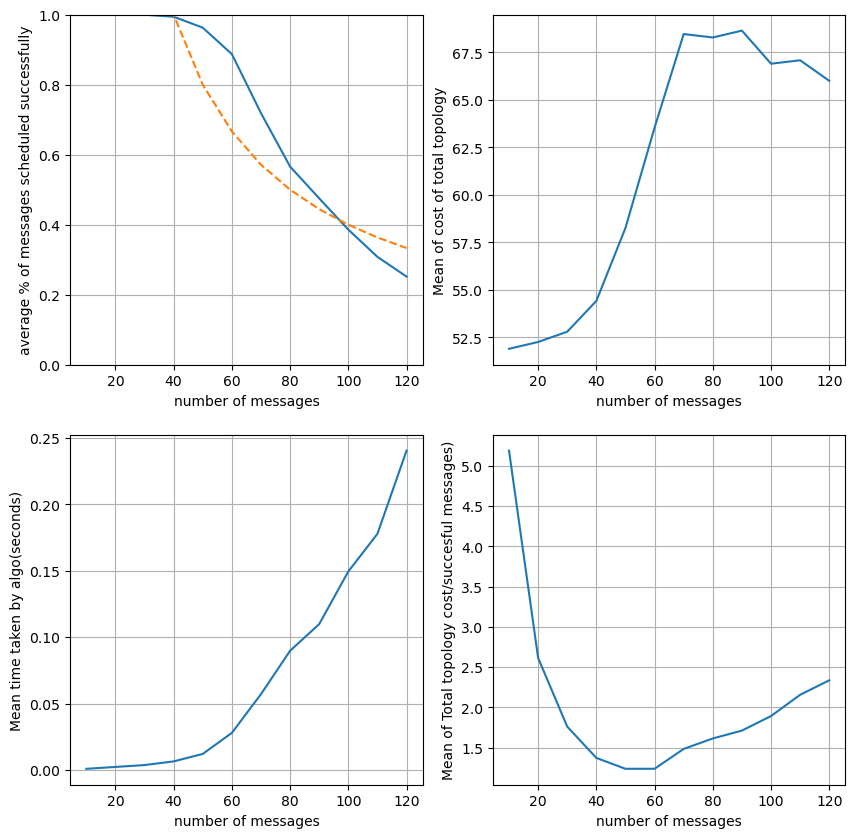

In [11]:
fig, ax = plt.subplots(2,2,figsize = (10,10))
ax[0][0].plot([10,20,30,40,50,60,70,80,90,100,110,120], p)
ax[0][0].plot([10,20,30,40,50,60,70,80,90,100,110,120],[40/i for i in [10,20,30,40,50,60,70,80,90,100,110,120]],linestyle = 'dashed')
ax[0][0].set_ylabel("average % of messages scheduled successfully",)
ax[0][0].set_xlabel("number of messages")
ax[0][0].grid(True)
ax[0][0].set_ylim(0, 1.0)

ax[0][1].plot([10,20,30,40,50,60,70,80,90,100,110,120], costs)
ax[0][1].set_ylabel("Mean of cost of total topology")
ax[0][1].set_xlabel("number of messages")
ax[0][1].grid(True)

ax[1][0].plot([10,20,30,40,50,60,70,80,90,100,110,120], times)
ax[1][0].set_ylabel("Mean time taken by algo(seconds)")
ax[1][0].set_xlabel("number of messages")
ax[1][0].grid(True)

ax[1][1].plot([10,20,30,40,50,60,70,80,90,100,110,120], costs_per_successful_message)
ax[1][1].set_ylabel("Mean of Total topology cost/succesful messages)")
ax[1][1].set_xlabel("number of messages")
ax[1][1].grid(True)

In [ ]:
import matplotlib.pyplot as plt
num_ecu = 8
num_bridges = 8
bridge_limit = 4
link_build_cost = 2


base_period = int(1e2 // 12)

period_choice = tsn.VectorInt([1,2,3,10])
period_choice_weights = tsn.Vectordouble([0.1,0.1,0.15,0.65])

min_size = 1
max_size = 1

min_tl = 2
max_tl = 2

runingtime_bridgevariation_tl2 = {}

for num_bridges in [4,8,12,16,20]:
    times = []
    costs_per_successful_message = []
    costs = []
    p = []
    
    for num_messages in [(num_ecu)*i for i in [5,10,15,20,25]]:
        print(f"Num Messages: {num_messages}")
        success = 0
        cost_per_succesful_message = 0
        cost = 0
        total_time = 0
        for runs in range(20):
            M = tsn.makeInputs(num_ecu,num_bridges,num_messages,base_period,period_choice,period_choice_weights,min_size,max_size,min_tl,max_tl,runs)

            starttime = time.time()
            output = tsn.algo(num_ecu,num_ecu,M,bridge_limit)
            endtime = time.time()

            temp = successfulPercetage(M,output)
            total_time += endtime - starttime
            success += temp
            cost_per_succesful_message += output.Cost / (temp * num_messages)
            cost += output.Cost
     

        p.append(success/20)
        times.append(total_time/20)
        costs_per_successful_message.append(cost_per_succesful_message/20)
        costs.append(cost/20)
       
    runingtime_bridgevariation_tl2[num_bridges] = {"runTime":times,
                                                   "sucPercent":p,
                                                   "cost_per_successful_message":costs_per_successful_message,
                                                   "Total Costs":costs}


Num Messages: 40
Num Messages: 80
Num Messages: 120
Num Messages: 160
Num Messages: 200
Num Messages: 40
Num Messages: 80
Num Messages: 120
Num Messages: 160
Num Messages: 200
Num Messages: 40
Num Messages: 80
Num Messages: 120
Num Messages: 160
Num Messages: 200
Num Messages: 40
Num Messages: 80
Num Messages: 120
Num Messages: 160
Num Messages: 200
Num Messages: 40
Num Messages: 80
Num Messages: 120
Num Messages: 160
Num Messages: 200


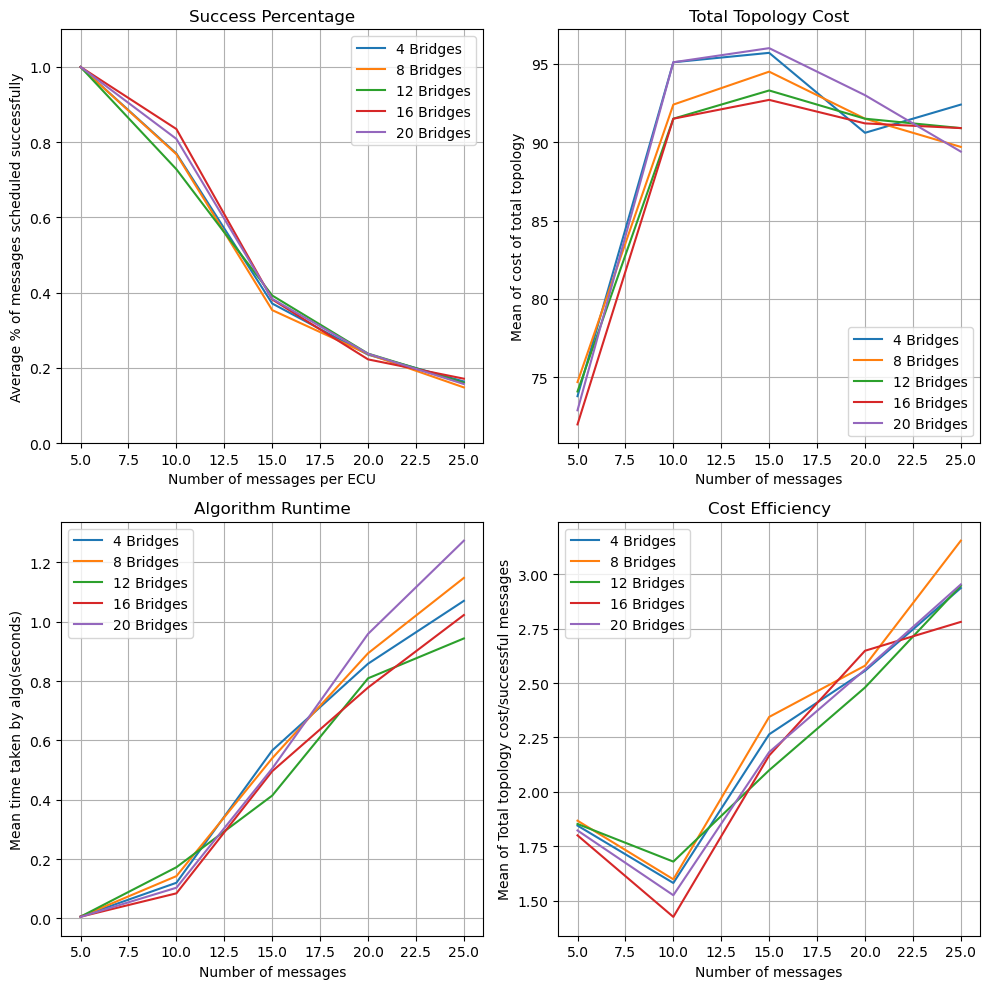

In [13]:
fig, ax = plt.subplots(2,2,figsize = (10,10))
x_values = [5,10,15,20,25]
for k in [4,8,12,16,20]:
    # 0,0: Success Percentage
    ax[0][0].plot(x_values, runingtime_bridgevariation_tl2[k]["sucPercent"], label=f"{k} Bridges")
    
    # 0,1: Total Topology Costs
    ax[0][1].plot(x_values, runingtime_bridgevariation_tl2[k]["Total Costs"], label=f"{k} Bridges")
    
    # 1,0: Mean Runtime
    ax[1][0].plot(x_values, runingtime_bridgevariation_tl2[k]["runTime"], label=f"{k} Bridges")
    
    # 1,1: Cost per Successful Message
    ax[1][1].plot(x_values, runingtime_bridgevariation_tl2[k]["cost_per_successful_message"], label=f"{k} Bridges")

ax[0][0].set_title("Success Percentage")
ax[0][0].set_ylabel("Average % of messages scheduled successfully")
ax[0][0].set_xlabel("Number of messages per ECU")
ax[0][0].set_ylim(0, 1.1) # Adjusted to see 100% clearly
ax[0][0].grid(True)
ax[0][0].legend()

ax[0][1].set_title("Total Topology Cost")
ax[0][1].set_ylabel("Mean of cost of total topology")
ax[0][1].set_xlabel("Number of messages")
ax[0][1].grid(True)
ax[0][1].legend()

ax[1][0].set_title("Algorithm Runtime")
ax[1][0].set_ylabel("Mean time taken by algo(seconds)")
ax[1][0].set_xlabel("Number of messages")
ax[1][0].grid(True)
ax[1][0].legend()

ax[1][1].set_title("Cost Efficiency")
ax[1][1].set_ylabel("Mean of Total topology cost/successful messages")
ax[1][1].set_xlabel("Number of messages")
ax[1][1].grid(True)
ax[1][1].legend()

plt.tight_layout()
plt.show()

In [3]:
import matplotlib.pyplot as plt
num_ecu = 8
num_bridges = 8
bridge_limit = 4
link_build_cost = 2


base_period = int(1e2 // 12)

period_choice = tsn.VectorInt([1,2,3,10])
period_choice_weights = tsn.Vectordouble([0.1,0.1,0.15,0.65])

min_size = 1
max_size = 1

min_tl = 2
max_tl = 2

runingtime_tl2 = {}

for num_ecu in [8,16]:
    times = []
    for num_messages in [(num_ecu)*i for i in [5,10,15,20]]:
        print(f"Num Messages: {num_messages}")
        total_time = 0
        for runs in range(5):
            M = tsn.makeInputs(num_ecu,num_ecu//4,num_messages,base_period,period_choice,period_choice_weights,min_size,max_size,min_tl,max_tl,runs)

            starttime = time.time()
            output = tsn.algo(num_ecu,num_ecu//4,M,bridge_limit)
            endtime = time.time()

            temp = successfulPercetage(M,output)
            total_time += endtime - starttime

        times.append(total_time/5)
    runingtime_tl2[num_ecu] = times


Num Messages: 40
Num Messages: 80
Num Messages: 120
Num Messages: 160
Num Messages: 80
Num Messages: 160
Num Messages: 240
Num Messages: 320


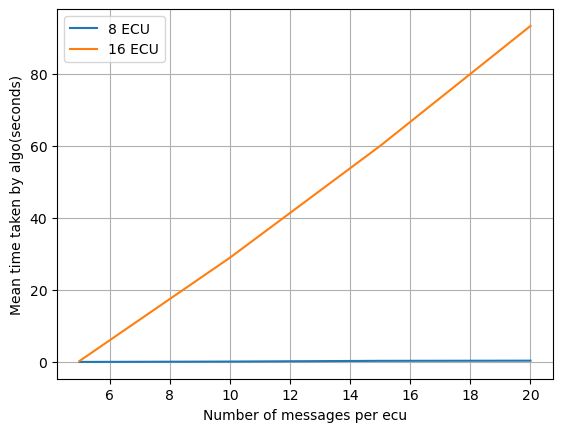

In [4]:
plt.plot([5,10,15,20], runingtime_tl2[8],label = "8 ECU")
plt.plot([5,10,15,20], runingtime_tl2[16],label = "16 ECU")

plt.ylabel("Mean time taken by algo(seconds)")
plt.xlabel("Number of messages per ecu")
plt.legend()
plt.grid(True)
plt.show()